In [2]:
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

import pandas as pd 
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

from functions import *

from micom import Community

# Dropout and Dropins - creation and analysis
- growth rates of community and individual 
- metabolite exchanges

## 1. Setup

In [3]:
community_dir = "/home/emma/Dokumente/thesis/communities/simulations"
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/final"
save_fig_dir = "/home/emma/Dokumente/thesis/git_repository/data/plotsnfigs"

In [4]:
dropout_dir = os.path.join(community_dir, "dropouts")

In [5]:
dropout_dir_HvSC1 = os.path.join(community_dir, "dropouts/HvSC1")
dropout_dir_HvSC2 = os.path.join(community_dir, "dropouts/HvSC2")

In [6]:
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [6]:
af_complete = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c1i127.csv", names = ["reaction", "flux"])

In [7]:
af_complete_d = create_medium(af_complete)

In [7]:
# define fontsizes

axis_labels = 22
title_size = 26
subtitle_size = 24
legend_size = 22
tick_size = 20


hvsc1_color = "#F2B342"
hvsc2_color = "#317EC2"
drop_in_color = "#09877F"
drop_out_color = "#ED6C02"
shared_color = "#24C136"
color_dict = {"HvSC1": hvsc1_color, "HvSC2": hvsc2_color, "Drop-In 892": drop_in_color, "Drop-Out 892": drop_out_color}


## 2. Create all dropouts

In [12]:
def dropout_coms_df(complete_df):
    drop_coms_df = {}
    for strain in complete_df["id"]:
        drop_com_id = f"drop_{strain}"
        com_drop = complete_df[complete_df["id"] != strain].copy()
        com_drop["abundance"] = com_drop["abundance"] / com_drop["abundance"].sum()
        drop_coms_df[drop_com_id] = com_drop
    return drop_coms_df
    

In [23]:
def pairwise_dropouts_df(complete_df):
    pw_drop_coms_df = {}
    pw_combinations = list(combinations(complete_df["id"], 2))
    for pair in pw_combinations:
        pair_str = pair[0] + "_" + pair[1]
        drop_com_id = f"drop_{pair_str}"
        com_drop = complete_df[~complete_df["id"].isin(pair)].copy()
        com_drop["abundance"] = com_drop["abundance"] / com_drop["abundance"].sum()
        pw_drop_coms_df[drop_com_id] = com_drop
    return pw_drop_coms_df

In [24]:
def dropout_coms(dropout_dfs, dropout_dir):
    dropout_dict = {}
    for com_id, com_df in dropout_dfs.items():
        file_id = f"{com_id}.pkl"
        if file_id not in os.listdir(dropout_dir):
            com = Community(com_df, id = com_id, name = com_id)
            dropout_dict[com_id] = com
            file_path = os.path.join(dropout_dir, f"{com_id}.pkl")
            with open(file_path, "wb") as f:
                pickle.dump(com, f)
    return dropout_dict

In [25]:
HvSC1_df_complete = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df_complete = HvSC1_df_complete[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df_complete["id"] = HvSC1_df_complete["id"].astype(str)
HvSC1_df_complete["abundance"] = 1
HvSC1_df_complete["file"] = HvSC1_df_complete['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [26]:
HvSC2_df_complete = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df_complete = HvSC2_df_complete[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df_complete["id"] = HvSC2_df_complete["id"].astype(str)
HvSC2_df_complete["abundance"] = 1
HvSC2_df_complete["file"] = HvSC2_df_complete['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [27]:
pw_sc1 = pairwise_dropouts_df(HvSC1_df_complete)

In [ ]:
HvSC1 = Community(HvSC1_df_complete, id = "HvSC1", name = "HvSC1") #create complete community as a control

Output()

In [ ]:
HvSC2 = Community(HvSC2_df_complete, id = "HvSC2", name = "HvSC2") #create complete community as a control

Output()

In [ ]:
HvSC1_drop_dfs = dropout_coms_df(HvSC1_df_complete)

In [ ]:
HvSC2_drop_dfs = dropout_coms_df(HvSC2_df_complete)

In [ ]:
HvSC1_drop_coms = dropout_coms(HvSC1_drop_dfs, dropout_dir_HvSC1)

Output()

In [ ]:
HvSC2_drop_coms = dropout_coms(HvSC2_drop_dfs, dropout_dir_HvSC2)

Output()

## 3. Analyze the dropouts

##### Format data

In [9]:
control_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_individualtaxon_growth.csv")
control_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_individualtaxon_growth.csv")

In [10]:
sc1_com_gr = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/dropouts/HvSC1/community_growth.csv")
sc2_com_gr = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/dropouts/HvSC2/community_growth.csv")

In [11]:
sc1_com_indigr = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/dropouts/HvSC1/individual_growth.csv")
sc2_com_indigr = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/dropouts/HvSC2/individual_growth.csv")

In [12]:
taxa_sc1 = sc1_com_indigr["Unnamed: 0"]
taxa_sc2 = sc2_com_indigr["Unnamed: 0"]

In [13]:
sc1_com_indigr = sc1_com_indigr.loc[:, sc1_com_indigr.iloc[0] == "growth_rate"].copy()
sc1_com_indigr = sc1_com_indigr.iloc[2:, :].copy()
sc1_com_indigr["taxon"] = taxa_sc1
sc1_com_indigr = sc1_com_indigr.set_index("taxon")
sc1_com_indigr.columns = sc1_com_indigr.columns.str.split(".").str[0]
sc1_com_indigr.columns = sc1_com_indigr.columns.str.split("_").str[1]

sc2_com_indigr = sc2_com_indigr.loc[:, sc2_com_indigr.iloc[0] == "growth_rate"].copy()
sc2_com_indigr = sc2_com_indigr.iloc[2:, :].copy()
sc2_com_indigr["taxon"] = taxa_sc2
sc2_com_indigr = sc2_com_indigr.set_index("taxon")
sc2_com_indigr.columns = sc2_com_indigr.columns.str.split(".").str[0]
sc2_com_indigr.columns = sc2_com_indigr.columns.str.split("_").str[1]

In [14]:
sc1_com_t = sc1_com_gr.set_index("Unnamed: 0").T
sc1_com_t.columns = sc1_com_t.columns.str.split(".").str[0]
sc1_com_t.columns = sc1_com_t.columns.str.split("_").str[1]

sc2_com_t = sc2_com_gr.set_index("Unnamed: 0").T
sc2_com_t.columns = sc2_com_t.columns.str.split(".").str[0]
sc2_com_t.columns = sc2_com_t.columns.str.split("_").str[1]

In [15]:
# add whole community data, and sort
dropout_growth_sc1 = pd.concat([sc1_com_indigr, sc1_com_t], axis=0)
dropout_growth_sc1 = dropout_growth_sc1.sort_index()
idx_sc1 = dropout_growth_sc1.index != "community_growth"
dropout_growth_sc1["complete_com"] = control_sc1["growth_rate"].values
dropout_growth_sc1.loc[idx_sc1] = (dropout_growth_sc1.loc[idx_sc1].astype(float) / len(dropout_growth_sc1))
exp_cols = sorted([col for col in dropout_growth_sc1.columns if col != "complete_com"])
dropout_growth_sc1 = dropout_growth_sc1[exp_cols + ["complete_com"]].astype(float)
dropout_growth_sc1.loc["community_growth", "complete_com"] = 7.534438744858953


dropout_growth_sc2 = pd.concat([sc2_com_indigr, sc2_com_t], axis=0)
dropout_growth_sc2 = dropout_growth_sc2.sort_index()
idx_sc2 = dropout_growth_sc2.index != "community_growth"
dropout_growth_sc2["complete_com"] = control_sc2["growth_rate"].values
dropout_growth_sc2.loc[idx_sc2] = (dropout_growth_sc2.loc[idx_sc2].astype(float) / len(dropout_growth_sc2))
exp_cols2 = sorted([col for col in dropout_growth_sc2.columns if col != "complete_com"])
dropout_growth_sc2 = dropout_growth_sc2[exp_cols2 + ["complete_com"]].astype(float)
dropout_growth_sc2.loc["community_growth", "complete_com"] = 5.94597147047921

In [16]:
# compute difference to whole community growth 
deltagrowth_sc1 = dropout_growth_sc1.sub(dropout_growth_sc1["complete_com"], axis=0)
deltagrowth_sc2 = dropout_growth_sc2.sub(dropout_growth_sc2["complete_com"], axis=0)
deltagrowth_sc1 = deltagrowth_sc1.drop(columns="complete_com")
deltagrowth_sc2 = deltagrowth_sc2.drop(columns="complete_com")

##### Plot

/tmp/ipykernel_45824/642929782.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


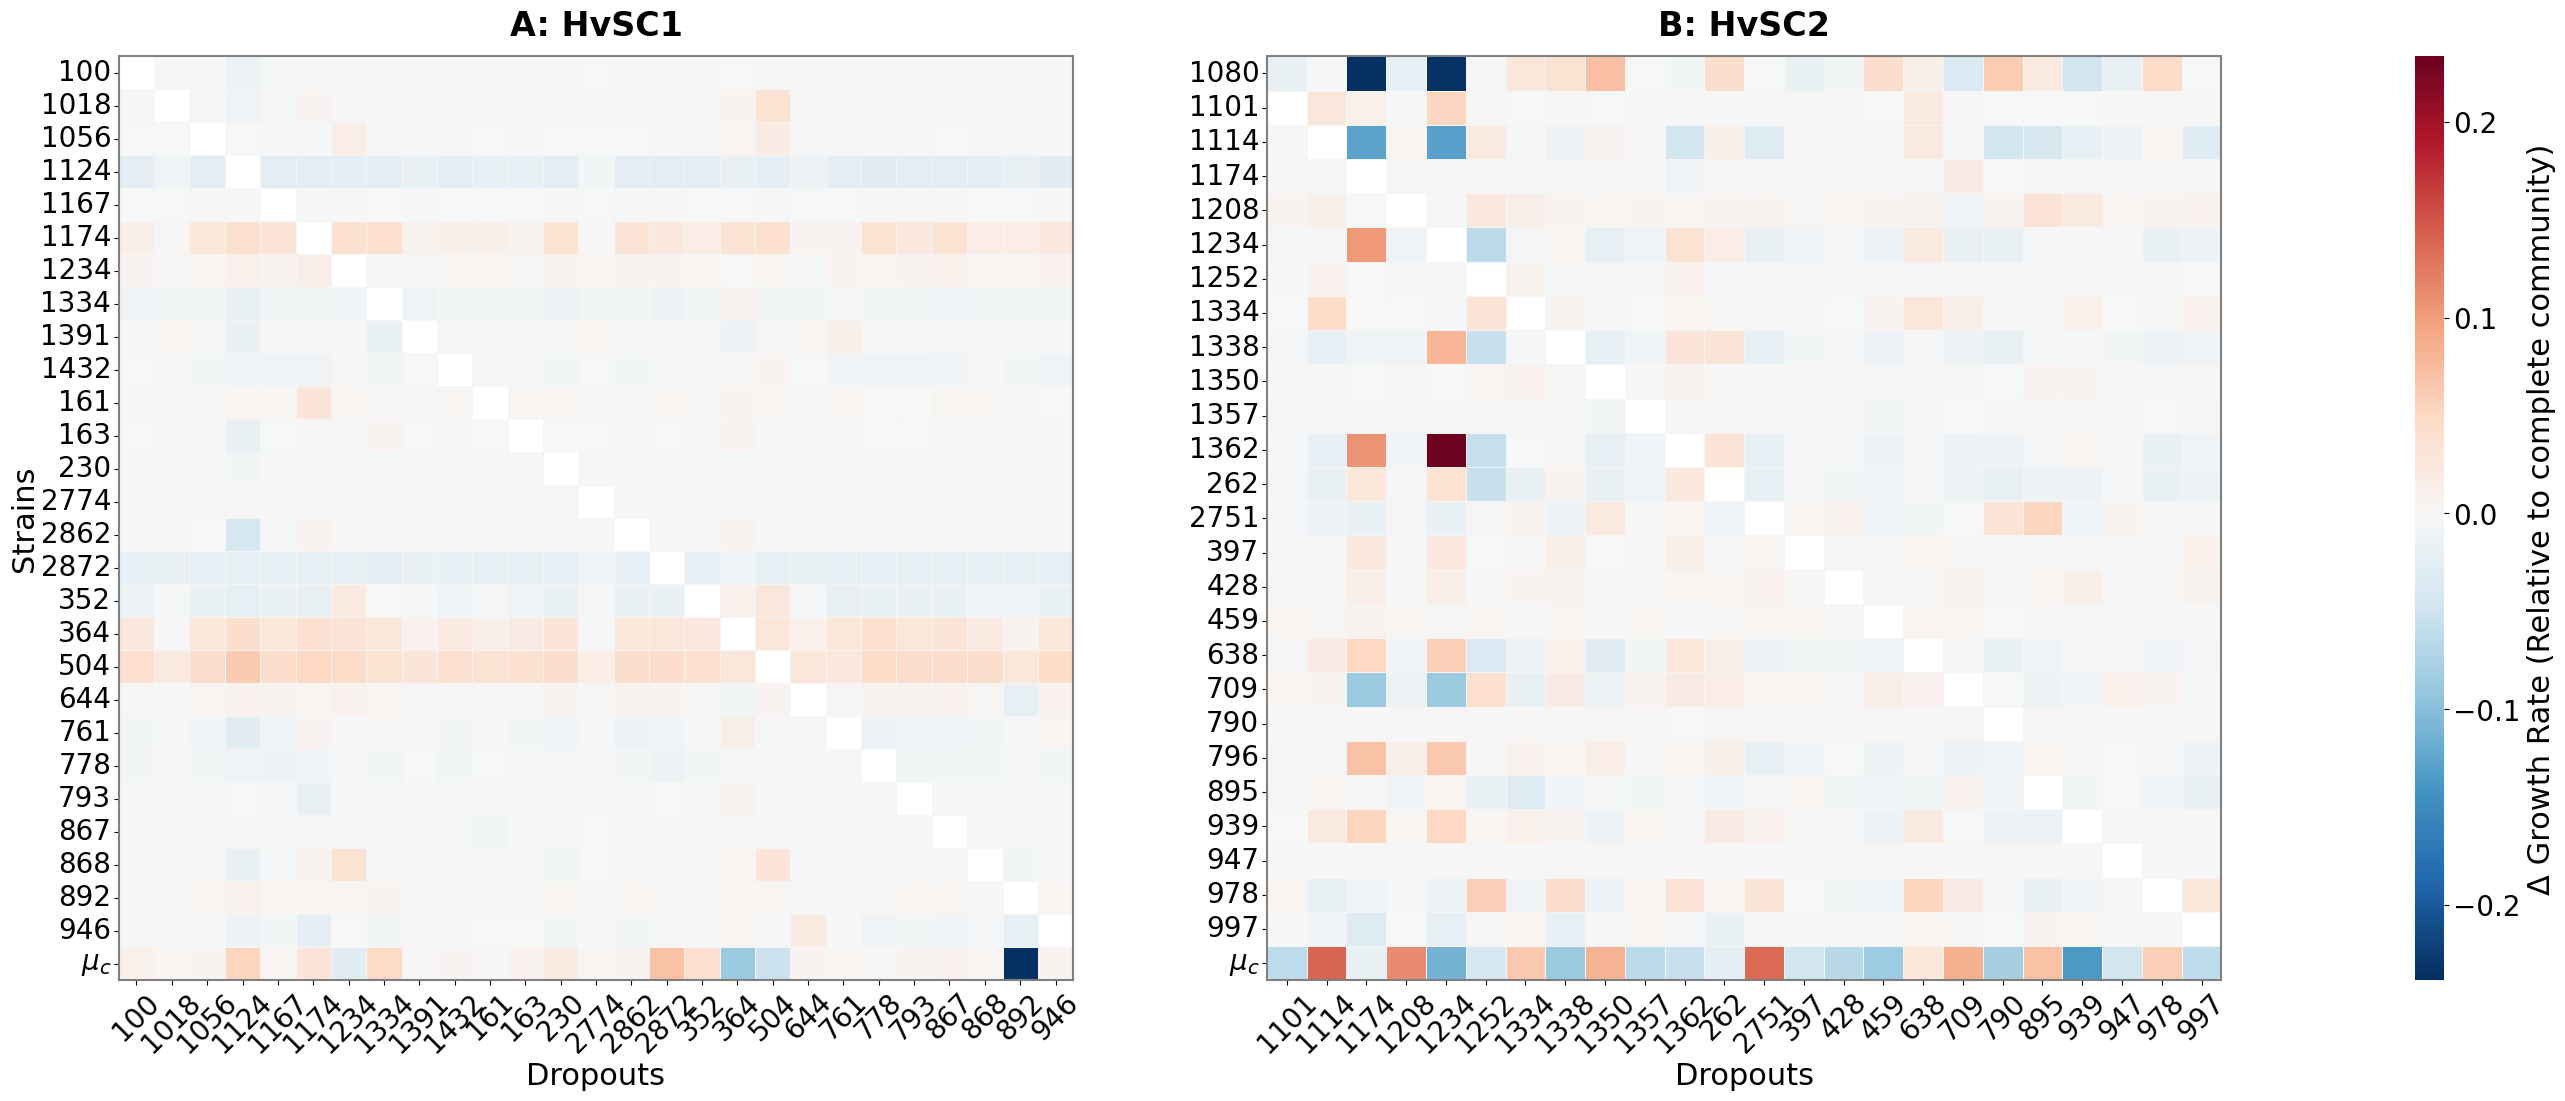

In [ ]:
df1_plot = deltagrowth_sc1.astype(float)
df2_plot = deltagrowth_sc2.astype(float)

df1_plot = df1_plot.rename(index={'community_growth': '$µ_c$'}, columns={'community_growth': '$µ_c$'})
df2_plot = df2_plot.rename(index={'community_growth': '$µ_c$'}, columns={'community_growth': '$µ_c$'})

# Setup Figure
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize=(30, 12), 
    sharey=False,
    gridspec_kw={'width_ratios': [1, 1, 0.03], 'wspace': 0.3}
)


heatmap_kwargs = dict(
    cmap="RdBu_r",
    center = 0.0,
    linewidths=0.5,
    linecolor='whitesmoke'
)

# Plot Heatmaps
sns.heatmap(df1_plot, ax=ax1, cbar=False, **heatmap_kwargs)
sns.heatmap(df2_plot, ax=ax2, cbar_ax=cbar_ax, cbar_kws={'label': 'Difference in Growth compared to Complete Community'}, **heatmap_kwargs)

ax1.set_title("A: HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.set_xlabel("Dropouts", fontsize=axis_labels, labelpad=3)   # Reduced padding closer to ticks
ax1.set_ylabel("Strains", fontsize=axis_labels, labelpad=1)      # Reduced padding closer to ticks

ax2.set_title("B: HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.set_xlabel("Dropouts", fontsize=axis_labels, labelpad=3)  # Reduced padding closer to ticks

for ax in (ax1, ax2):
    ax.tick_params(axis="both", labelsize=tick_size, pad=2) 
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('grey')
        spine.set_linewidth(1.5)

cbar = ax2.collections[0].colorbar
cbar.set_label('Δ Growth Rate (Relative to complete community)', size=legend_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.tight_layout(rect=[0, 0, 1, 0.94])

fp_svg = os.path.join(save_fig_dir, "Dropout_growthrates.svg")
fp_png = os.path.join(save_fig_dir, "Dropout_growthrates.png")

plt.savefig(fp_png, format='png', bbox_inches='tight', dpi=300)
plt.savefig(fp_svg, format='svg', bbox_inches='tight', dpi=300)
plt.show()

##### plot changes in HvSC1 structure - not included in the thesis but good to see!

In [52]:
indigrowth_drop892 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/dropouts/HvSC1/individual_growth.csv")
indigrowth_drop892 = indigrowth_drop892["drop_892.pkl.1"].dropna().drop(0)
indigrowth_drop892 = indigrowth_drop892.astype(float) / len(indigrowth_drop892)

In [36]:
gr_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_individualtaxon_growth.csv")
gr_sc1["scaled_growth"] = gr_sc1[gr_sc1["compartments"] != "medium"]["growth_rate"] / len(gr_sc1[gr_sc1["compartments"] != "medium"])

In [54]:
combined_gr = pd.concat([gr_sc1.assign(syncom="HvSC1"), indigrowth_drop892.to_frame("scaled_growth").assign(syncom="Drop-Out 892")], ignore_index=True).dropna(subset=["scaled_growth"])

/tmp/ipykernel_17019/2129879095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


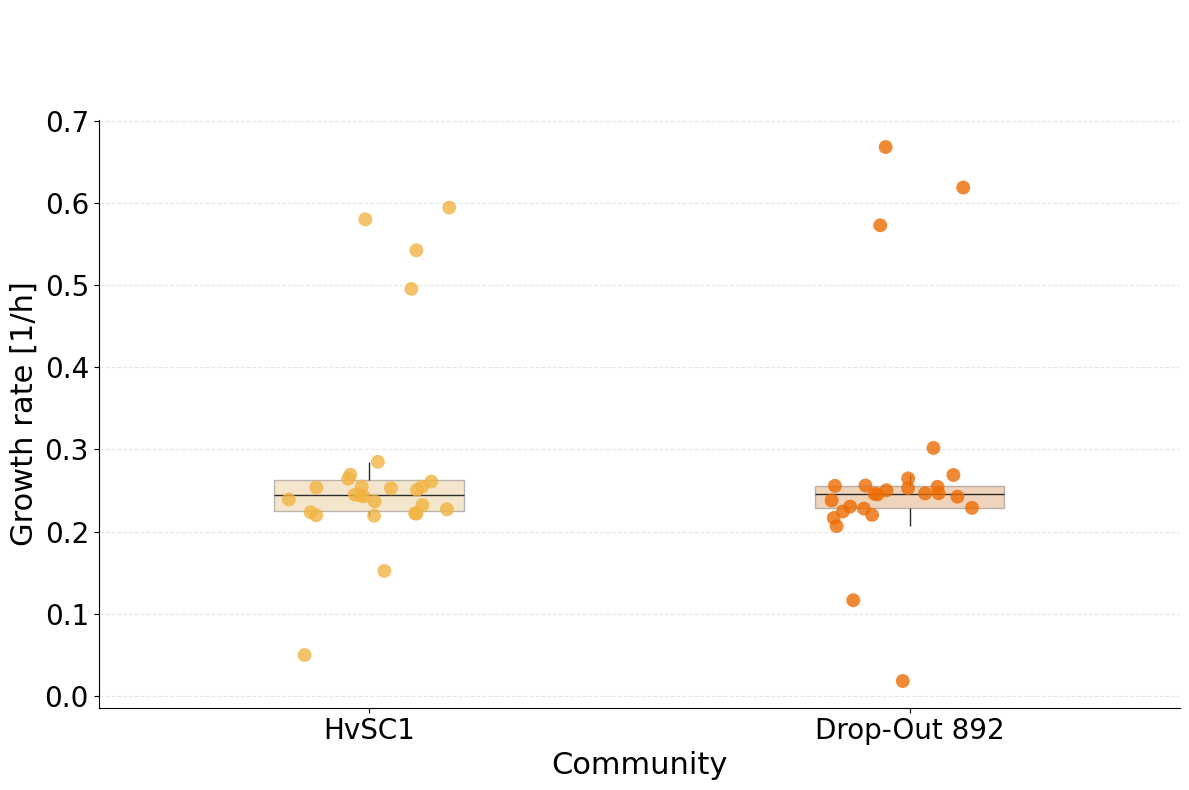

In [58]:
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Boxplot
sns.boxplot(
    data=combined_gr,
    x="syncom", y="scaled_growth",
    palette=color_dict,
    width=0.35,
    boxprops=dict(alpha=0.3),
    showcaps=False, showfliers=False,
    ax=ax) 

# 2. Main Stripplot
sns.stripplot(
    data=combined_gr,
    x="syncom", y="scaled_growth",
    hue="syncom",
    palette=color_dict,
    jitter=0.15,
    alpha=0.8,
    size=10,
    ax=ax,
    legend=False) 
'''
ax.text(x=1, y=0.62, 
    s="$\mu_c$: 6.437", 
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=drop_in_color, alpha=0.2, edgecolor=drop_out_color))
ax.text(x=0, y=0.62, 
    s="$\mu_c$: 5.945", 
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=hvsc2_color, alpha=0.2, edgecolor=hvsc1_color))'''

ax.set_title(" ", fontsize=title_size, pad=60)
ax.set_xlabel("Community", fontsize=axis_labels)
ax.set_ylabel("Growth rate [1/h]", fontsize=axis_labels)

ax.tick_params(axis="both", labelsize=tick_size)
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
sns.despine(ax=ax)

plt.tight_layout()
fp = os.path.join(save_fig_dir, "DROPOUT892_Individual_growthrates_boxplot_l2pfba.svg")
#plt.savefig(fp, bbox_inches='tight')
plt.show()

## 4. Drop-in 892

### 4.1 Create drop-in community

In [13]:
HvSC2_892_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both") | (taxonomy_df["Strain ID"] == 892)]
HvSC2_892_df = HvSC2_892_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_892_df["id"] = HvSC2_892_df["id"].astype(str)
HvSC2_892_df["abundance"] = 1
HvSC2_892_df["file"] = HvSC2_892_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [15]:
HvSC2_892 = Community(HvSC2_892_df, id = "HvSC2_892", name = "HvSC2_892")

Output()

### 4.2 Simulate growth

In [16]:
fraction = [1]

In [34]:
HvSC2_892.medium = af_complete_d

In [18]:
solution_sc2_892 = run_l2_then_pfba(HvSC2_892, fractions=fraction)

optimal solution: 6.437879505911612
---------
Tradeoff-value: 1
Community objective: 6.437135719296653
pFBA solution (total flux): 233076.48571240954
---------


In [53]:
solution_sc2_892.iloc[0]["solution"].members["scaled_growth"] = solution_sc2_892.iloc[0]["solution"].members["growth_rate"] / len(HvSC2_892_df)

In [86]:
save_tradeoff_results(solution_sc2_892, community_dir, "DropIN892_HvSC2")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations


In [8]:
gr_sc2_892 = pd.read_csv("/home/emma/Dokumente/thesis/git_repository/data/communities/dropouts/HvSC2/dropin_892/HvSC2_892_l2pfba_10_individualtaxon_growth.csv")

In [9]:
gr_sc2_892["scaled_growth"] = gr_sc2_892["growth_rate"] / len(gr_sc2_892)

In [10]:
gr_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_individualtaxon_growth.csv")
gr_sc2["scaled_growth"] = gr_sc2["growth_rate"] / len(gr_sc2)

In [11]:
combined_gr = pd.concat([gr_sc2.assign(syncom="HvSC2"), gr_sc2_892.assign(syncom="Drop-In 892")], ignore_index=True).dropna(subset=["scaled_growth"])

In [12]:
avg_growth_sc2 = gr_sc2["scaled_growth"].median()
avg_growth_sc2_892 = gr_sc2_892["scaled_growth"].median()


iqr_sc2 = gr_sc2["scaled_growth"].quantile(0.75) - gr_sc2["scaled_growth"].quantile(0.25)
iqr_sc2_892 = gr_sc2_892["scaled_growth"].quantile(0.75) - gr_sc2_892["scaled_growth"].quantile(0.25)

print(f"HvSC2 - Median: {avg_growth_sc2:.4f}, IQR: {iqr_sc2:.4f}")
print(f"Drop-In 892 - Median: {avg_growth_sc2_892:.4f}, IQR: {iqr_sc2_892:.4f}")

HvSC2 - Median: 0.2123, IQR: 0.0889
Drop-In 892 - Median: 0.2193, IQR: 0.1726


/tmp/ipykernel_16358/1035095298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


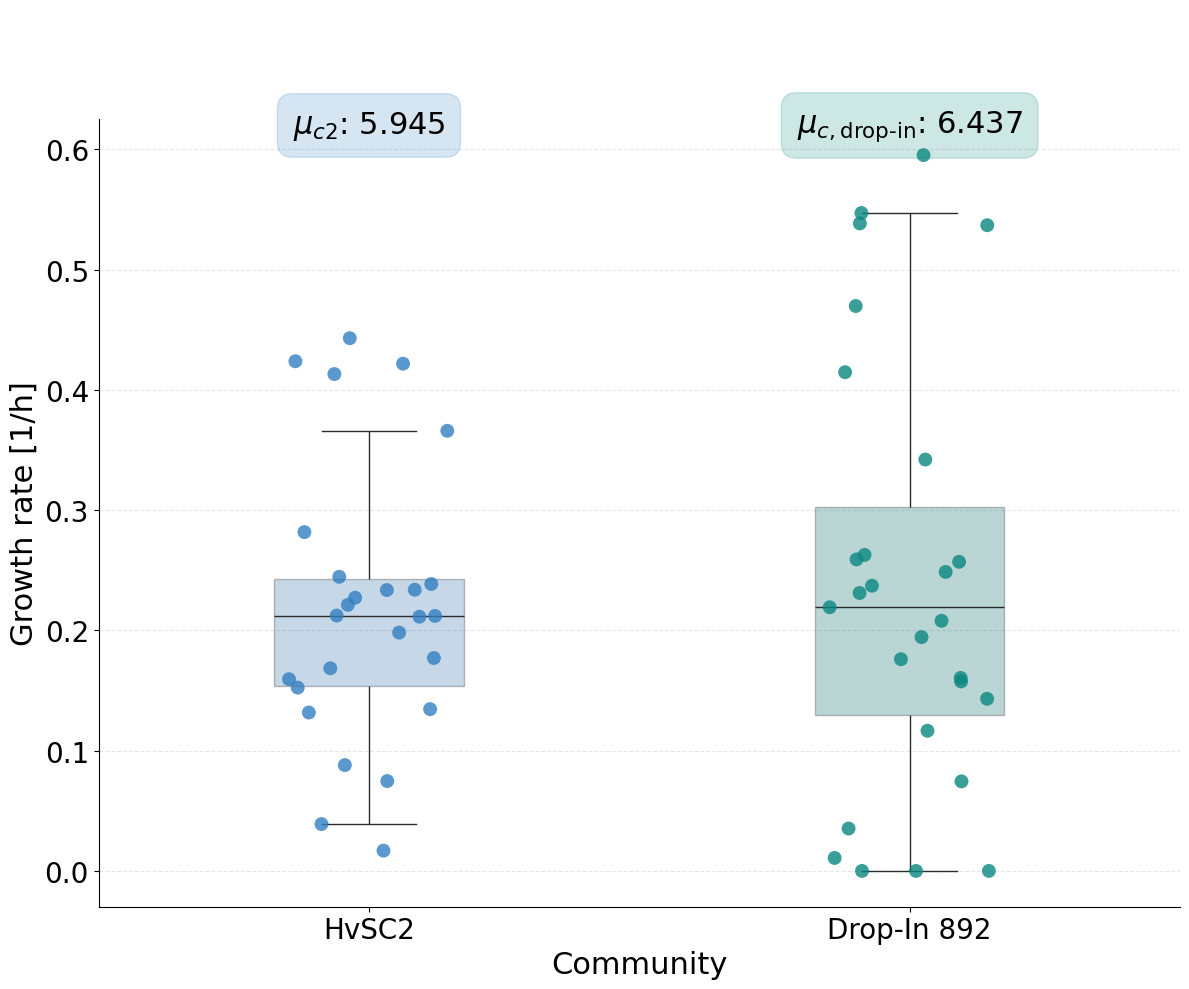

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Boxplot
sns.boxplot(
    data=combined_gr,
    x="syncom", y="scaled_growth",
    palette=color_dict,
    width=0.35,
    boxprops=dict(alpha=0.3),
    showcaps=True, showfliers=False,
    ax=ax) 

# 2. Main Stripplot
sns.stripplot(
    data=combined_gr,
    x="syncom", y="scaled_growth",
    hue="syncom",
    palette=color_dict,
    jitter=0.15,
    alpha=0.8,
    size=10,
    ax=ax,
    legend=False) 

ax.text(
    x=1, y=0.62,
    s=r"$\mu_{c,\mathrm{drop\text{-}in}}$: 6.437",
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=drop_in_color, alpha=0.2, edgecolor=drop_in_color)
)
ax.text(x=0, y=0.62, 
    s="$\mu_{c2}$: 5.945", 
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=hvsc2_color, alpha=0.2, edgecolor=hvsc2_color))

ax.set_title(" ", fontsize=title_size, pad=60)
ax.set_xlabel("Community", fontsize=axis_labels)
ax.set_ylabel("Growth rate [1/h]", fontsize=axis_labels)

ax.tick_params(axis="both", labelsize=tick_size)
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
sns.despine(ax=ax)

plt.tight_layout()
fp = os.path.join(save_fig_dir, "DROPIN892_Individual_growthrates_boxplot_l2pfba.svg")

fp = os.path.join(save_fig_dir, "DROPIN892_Individual_growthrates_boxplot_l2pfba.png")
plt.savefig(fp, bbox_inches='tight')
plt.show()

### 4.3 How do metabolic interactions change in dropin community?

In [59]:
def filter_h2o_h_o2(df):
    mets2filter = ["EX_h2o_e", "EX_o2_e", "EX_h_e", "EX_h2_e"]
    filtered_df = df[df["reaction"].apply(lambda x: x not in mets2filter)]
    return filtered_df

In [60]:
# load fluxes from community simulations
dropin_fluxes1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/DropIN892_HvSC2_10_fluxes.csv", index_col= "compartment")
HvSC2_fluxes1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_fluxes.csv", index_col = "compartment")
interactions_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_interactions.csv")


In [61]:
dropin_fluxes1_clean = tidy_exchange_fluxes(dropin_fluxes1)
HvSC2_fluxes1_clean = tidy_exchange_fluxes(HvSC2_fluxes1)

dropin_fluxes1_clean = filter_h2o_h_o2(dropin_fluxes1_clean)
HvSC2_fluxes1_clean = filter_h2o_h_o2(HvSC2_fluxes1_clean)

In [62]:
active_exchanges_dropin = dropin_fluxes1_clean[dropin_fluxes1_clean["taxon"] != "medium"]
summary_exchanges_dropin = active_exchanges_dropin.groupby(["taxon", "direction"])["flux"].agg(count="count", sum_flux="sum").unstack(fill_value=0)
summary_exchanges_dropin.columns = [f"{metric}_{direction.replace('import', 'uptakes').replace('export', 'secretions')}" for metric, direction in summary_exchanges_dropin.columns]
summary_exchanges_dropin = summary_exchanges_dropin.reindex(columns=["count_uptakes", "sum_flux_uptakes", "count_secretions", "sum_flux_secretions"], fill_value=0).sort_values(by="count_uptakes", ascending=False)

# only negative fluxes (uptakes)
uptake_dropin = active_exchanges_dropin[active_exchanges_dropin["direction"] == "import"].sort_values(by="flux", ascending = False)

# only positive fluxes (secretions)
secrete_dropin = active_exchanges_dropin[active_exchanges_dropin["direction"] == "export"]


In [63]:
taxa_uptakes_dropin = uptake_dropin.groupby("taxon")["reaction"].apply(set)

In [64]:
mro_dropin = mro_score(taxa_uptakes_dropin)

print(f"MRO score: {mro_dropin} Dropin")

MRO score: 0.49807156631669164 Dropin


In [65]:
interactions_dropin = get_interactions(dropin_fluxes1_clean)

/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the groupi

In [96]:
interactions_dropin.to_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/DROPIN892_interactions.csv")

In [113]:
mets2filter = ["EX_h2o_e", "EX_o2_e", "EX_h_e"]
metsfiltered_sc2 = interactions_sc2[interactions_sc2["reaction"].apply(lambda x: x not in mets2filter)]

In [66]:
filtered_dropin = interactions_dropin[(interactions_dropin["class"] == "received") | (interactions_dropin["class"] == "provided")]
#filtered_sc2 = metsfiltered_sc2[(metsfiltered_sc2["class"] == "received") | (metsfiltered_sc2["class"] == "provided")]

In [67]:
# count number of exchanges per partners
filtered_dropin[(filtered_dropin["focal"] == "892") & (filtered_dropin["class"] == "provided")]["partner"].value_counts()

partner
895     6
262     6
978     4
428     4
939     4
796     4
1252    4
947     4
397     4
790     4
1208    3
459     3
997     3
1174    3
1338    3
1357    3
1101    3
1362    2
1234    2
709     2
1334    2
1350    2
1114    1
638     1
1080    1
Name: count, dtype: int64

In [69]:
# sum of provided fluxes by 892 per partner
for p in filtered_dropin[(filtered_dropin["focal"] == "892") & (filtered_dropin["class"] == "provided")]["partner"].unique():
    partner_flux = filtered_dropin[(filtered_dropin["focal"] == "892") & (filtered_dropin["class"] == "provided") & (filtered_dropin["partner"] == p)]["flux"].sum()
    mets_received = filtered_dropin[(filtered_dropin["focal"] == "892") & (filtered_dropin["class"] == "provided") & (filtered_dropin["partner"] == p)]["reaction"].tolist()
    print(f"Partner: {p}, Total Provided Flux: {partner_flux}, Metabolites: {mets_received}")

Partner: 1208, Total Provided Flux: 0.3603921284821717, Metabolites: ['EX_acald_e', 'EX_arg__L_e', 'EX_nh4_e']
Partner: 1334, Total Provided Flux: 0.7996326820759511, Metabolites: ['EX_arg__L_e', 'EX_glu__L_e']
Partner: 397, Total Provided Flux: 4.413909997199406, Metabolites: ['EX_acald_e', 'EX_arg__L_e', 'EX_co_e', 'EX_nh4_e']
Partner: 790, Total Provided Flux: 3.9557742079361926, Metabolites: ['EX_acald_e', 'EX_arg__L_e', 'EX_co_e', 'EX_glu__L_e']
Partner: 947, Total Provided Flux: 1.0820098018698783, Metabolites: ['EX_arg__L_e', 'EX_co_e', 'EX_nh4_e', 'EX_ppap_e']
Partner: 997, Total Provided Flux: 4.287341796814668, Metabolites: ['EX_acald_e', 'EX_arg__L_e', 'EX_nh4_e']
Partner: 1114, Total Provided Flux: 0.003316972884524746, Metabolites: ['EX_arg__L_e']
Partner: 1362, Total Provided Flux: 0.8113100248447871, Metabolites: ['EX_arg__L_e', 'EX_nh4_e']
Partner: 428, Total Provided Flux: 4.563958555199569, Metabolites: ['EX_acald_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']
Partner: 79

In [74]:
nitrate_exchange = filtered_dropin[(filtered_dropin["focal"] == "892") & (filtered_dropin["class"] == "provided")& (filtered_dropin["reaction"] == "EX_no3_e")]

In [76]:
nitrate_exchange

,focal,partner,reaction,class,flux
6750,892,428,EX_no3_e,provided,0.265428
6899,892,1338,EX_no3_e,provided,3.846154
6927,892,1357,EX_no3_e,provided,0.634886


In [118]:
coconsumption_dropin = interactions_dropin[(interactions_dropin["class"] == "co-consumed")]

In [119]:
medup_dropin, medup_dropin_list, comup_dropin, mip = uptake_mediumvscommunity(uptake_dropin, af_complete_d)

print(f"Dropin: {medup_dropin} from medium, {comup_dropin} from com, MIP: {mip}")

Dropin: 42 from medium, 518 from com, MIP: 0.925


In [101]:
fall_dropin, fcom_dropin , fmip1 = fMIP(uptake_dropin, af_complete_d)

print(f"Dropin: {fall_dropin} total , {fcom_dropin} from medium, fMIP: {fmip1}")


Dropin: -11534.717953830253 total , -5403.276936162058 from medium, fMIP: 0.5315640176214427
